In [1]:
#load library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import os,re,glob

# visualization setting
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.dpi'] = 100

print('라이브러리 임포트 완료')

라이브러리 임포트 완료


In [2]:
data_path = os.path.join(os.getcwd(), 'data','A_DeviceMotion_data')
if os.path.exists(data_path):
    print(f"데이터 경로 확인: {data_path}")
else:
    print("경로를 찾을 수 없습니다.")

데이터 경로 확인: /Users/linerenza/Desktop/비정형데이터분석/data/A_DeviceMotion_data


In [3]:
os.chdir(data_path) #change directory
#search for all data with csv format
fls = glob.glob("*/**/*.csv", recursive = True)
fls = [f.replace('.csv','') for f in fls] #remove .csv extension from file name
print(f'층 {len(fls)}개 파일이 발견:')
print(fls[:10])

층 360개 파일이 발견:
['dws_11/sub_12', 'dws_11/sub_1', 'dws_11/sub_13', 'dws_11/sub_11', 'dws_11/sub_2', 'dws_11/sub_3', 'dws_11/sub_10', 'dws_11/sub_14', 'dws_11/sub_7', 'dws_11/sub_6']


In [4]:
#load csv file into python dict
data_dict = {}
for f in fls :
    data_dict[f] = pd.read_csv(f + '.csv')
print(f'층 {len(data_dict)} 개 파일 로드 완료')
#preview
first_key = list(data_dict.keys())[0]
print(f'\n 샘믈 데이터({first_key})')
data_dict[first_key].head()

층 360 개 파일 로드 완료

 샘믈 데이터(dws_11/sub_12)


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049


In [5]:
#files filtering
#method 1
user_1 = [f for f in fls if f.endswith ('/sub_1')]
#method 2
#user_1 = [f for f in fls if re.search(r'sub_1\.',f + '.csv')]
print('subject #1 파일 목록"')
print(user_1)

subject #1 파일 목록"
['dws_11/sub_1', 'ups_12/sub_1', 'wlk_7/sub_1', 'std_14/sub_1', 'wlk_15/sub_1', 'wlk_8/sub_1', 'dws_2/sub_1', 'sit_13/sub_1', 'jog_9/sub_1', 'ups_3/sub_1', 'ups_4/sub_1', 'jog_16/sub_1', 'dws_1/sub_1', 'sit_5/sub_1', 'std_6/sub_1']


In [6]:
#filter only waking activity for subject 1
user_walking = [f for f in user_1 if 'wlk' in f]
print('subject #1 walking 파일 목록:')
print(user_walking)

subject #1 walking 파일 목록:
['wlk_7/sub_1', 'wlk_15/sub_1', 'wlk_8/sub_1']


In [7]:
#extract number from a file na,me
#파일명에서 숫자 추출 - re.findall 사용

example_f = 'wlk_exp8_sub19'
nums = re.findall(r'\d+', example_f)
print(f'파일 명: {example_f}')
print(f' 추출돤 솟자 목록: {nums}')
print(f'exp_no = {nums[0]}, id= {nums[1]}')


파일 명: wlk_exp8_sub19
 추출돤 솟자 목록: ['8', '19']
exp_no = 8, id= 19


In [8]:
# user1의 walking 데이터를 하나의 DataFrame으로 합치기

frames = []

for f in user_walking:
    temp = data_dict[f].copy()

    # 파일명에서 숫자 모두 추출
    nums = re.findall(r'\d+', f)

    # 첫 번째 숫자 = exp_no
    temp['exp_no'] = nums[0]

    # 두 번째 숫자 = id
    temp['id'] = nums[1]

    frames.append(temp)

# 모든 데이터프레임 합치기
user1_walking_total = pd.concat(frames, ignore_index=True)

print(f" 통합 DataFrame 크기: {user1_walking_total.shape}")

# 앞 데이터 확인
user1_walking_total.head()

 통합 DataFrame 크기: (11112, 15)


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id
0,0,-1.711140,-1.429168,-2.591433,-0.139767,0.989987,0.019745,-0.350593,-0.511691,-0.865217,0.091702,0.415881,0.093689,7,1
1,1,-1.787917,-1.414171,-2.630956,-0.152324,0.987759,0.033602,-0.550553,-2.243217,-0.582409,0.367412,0.004566,-0.106082,7,1
2,2,-1.897323,-1.399331,-2.706668,-0.161610,0.985336,0.054729,-0.931014,-1.358033,-0.503947,0.172093,-0.217483,-0.163387,7,1
3,3,-2.018375,-1.383279,-2.813421,-0.168058,0.982470,0.080680,-1.304668,-0.541368,-0.346302,0.004957,-0.237566,-0.019080,7,1
4,4,-2.124395,-1.364054,-2.913092,-0.174613,0.978705,0.107922,-1.278349,-0.434722,-0.398598,-0.040292,-0.241461,0.015201,7,1


In [9]:
#magnitude calculation function
#vector value into scalar value
def mag(df, var):

    df = df.copy()

    df[f'mag{var}'] = np.sqrt(
        df[f'{var}.x']**2 +
        df[f'{var}.y']**2 +
        df[f'{var}.z']**2
    )

    return df


In [10]:
user1_walking_total = mag(user1_walking_total,'userAcceleration')
print('maguserAcceleration 컬럼 생성 완료')

maguserAcceleration 컬럼 생성 완료


In [11]:
# exp_no  그룹별 상대 시간 (순번) 변수 생성

user1_walking_total['time'] = (
    user1_walking_total.groupby('exp_no').cumcount()+1 #0-index -> 1- index
)
print('time 컬럼 생성 완료')
#r각 실험별 최대 시간(샘플 수 ) 확인
print(user1_walking_total.groupby('exp_no')['time'].max())

time 컬럼 생성 완료
exp_no
15    1333
7     5439
8     4340
Name: time, dtype: int64


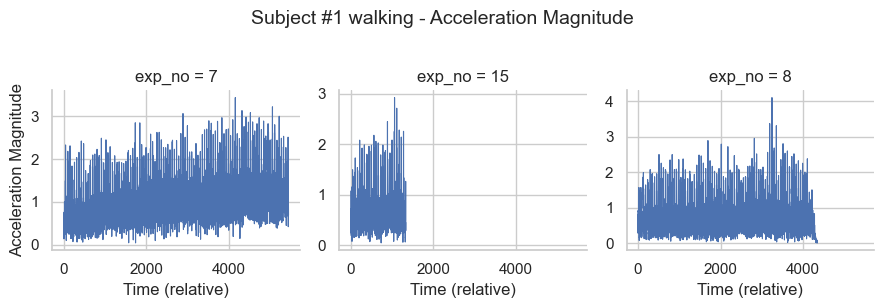

In [12]:
#시각화
g = sns.FacetGrid(
    user1_walking_total,
    col = 'exp_no',
    col_wrap = 3,
    height = 3,
    sharey = False
)
g.map(plt.plot, 'time', 'maguserAcceleration', linewidth = 0.8)
g.set_axis_labels('Time (relative)', 'Acceleration Magnitude')
g.figure.suptitle('Subject #1 walking - Acceleration Magnitude',
                  y = 1.02, fontsize = 14)
plt.tight_layout()
plt.show()

In [16]:
#전체 데이터 통합 (사람별 / 실험반호별 / 확동병)

frames = []
for f in fls:
    temp = data_dict[f].copy()
    nums = re.findall(r'\d+', f)
    temp['exp_no'] = nums[0] #실험 번호
    temp['id'] = nums[1] #사용자 ID
    temp['activity'] = f.split('_')[0] #파일명 첫 부분 = 활동명
    frames.append(temp)

HAR_total = pd.concat(frames, ignore_index = True)

print(f'전체 HAR DataFrame shape : {HAR_total.shape}')
print(f"포함된 활동 종류 : {HAR_total['activity'].unique()}")
HAR_total.head(100)

전체 HAR DataFrame shape : (1412865, 16)
포함된 활동 종류 : ['dws' 'ups' 'wlk' 'std' 'sit' 'jog']


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,-0.338641,-1.389441,1.720359,-0.059909,0.983600,-0.170095,0.936058,-2.362957,-0.925490,-0.661496,-0.394947,-0.028376,11,12,dws
96,96,-0.473490,-1.364870,1.626314,-0.093229,0.978872,-0.181957,0.772449,-2.062896,-1.495312,-0.315478,-0.042715,0.434933,11,12,dws
97,97,-0.606190,-1.337768,1.537740,-0.131556,0.972972,-0.189763,0.456903,-2.378597,-1.393494,-0.034841,0.409505,0.496892,11,12,dws
98,98,-0.692609,-1.323715,1.488223,-0.156160,0.969630,-0.188206,0.130423,-1.543524,-0.552949,0.414171,0.526173,0.411900,11,12,dws


In [18]:
#가속도(UserAcceleration) + 확전율(rotationRate) magnitude 생성

HAR_total = mag(HAR_total, 'userAcceleration')
HAR_total = mag(HAR_total, 'rotationRate')

print('magnitude 변수 생성 완료')
print(HAR_total.info())
HAR_total[['maguserAcceleration', 'magrotationRate']].describe()

magnitude 변수 생성 완료
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412865 entries, 0 to 1412864
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Unnamed: 0           1412865 non-null  int64  
 1   attitude.roll        1412865 non-null  float64
 2   attitude.pitch       1412865 non-null  float64
 3   attitude.yaw         1412865 non-null  float64
 4   gravity.x            1412865 non-null  float64
 5   gravity.y            1412865 non-null  float64
 6   gravity.z            1412865 non-null  float64
 7   rotationRate.x       1412865 non-null  float64
 8   rotationRate.y       1412865 non-null  float64
 9   rotationRate.z       1412865 non-null  float64
 10  userAcceleration.x   1412865 non-null  float64
 11  userAcceleration.y   1412865 non-null  float64
 12  userAcceleration.z   1412865 non-null  float64
 13  exp_no               1412865 non-null  object 
 14  id                   1412865 no

,maguserAcceleration,magrotationRate
count,1.412865e+06,1.412865e+06
mean,4.253801e-01,1.244030e+00
std,5.917344e-01,1.510491e+00
min,1.177879e-04,1.791647e-05
25%,2.662709e-02,2.777450e-02
50%,1.971418e-01,6.943342e-01
75%,6.181895e-01,2.070832e+00
max,1.011331e+01,2.196801e+01


In [19]:
display(HAR_total)

,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412860,7019,1.529437,-1.490474,-1.584437,0.080167,0.996776,-0.003318,-0.085002,-0.429722,-0.069257,0.022524,-0.038265,0.065039,6,23,std,0.078750,0.443489
1412861,7020,1.551358,-1.491945,-1.554159,0.078755,0.996893,-0.001531,-0.135020,-0.400788,-0.068575,0.032589,-0.005148,0.003789,6,23,std,0.033210,0.428444
1412862,7021,1.586295,-1.493207,-1.511671,0.077503,0.996992,0.001201,-0.183880,-0.342070,-0.058310,-0.019428,-0.004850,-0.001918,6,23,std,0.020116,0.392713
1412863,7022,1.629579,-1.493814,-1.462520,0.076774,0.997038,0.004518,-0.189980,-0.255930,-0.024317,-0.030082,0.006120,-0.003267,6,23,std,0.030872,0.319662


In [28]:
csv_path = f"{data_path}/HAR_total.csv"
pkl_path = f"{data_path}/HAR_total.pkl"

HAR_total.to_csv(csv_path, index=False)
HAR_total.to_pickle(pkl_path)
print("저장 완료")

저장 완료


In [21]:
#통계 특집 추출 (평균, 최소, 최대, 표준편차, 왜도)

HAR_summary = (
    HAR_total.groupby(['id','exp_no', 'activity'])[[
        'maguserAcceleration', 'magrotationRate'
    ]].agg(['mean', 'min','max','std',skew]).
    reset_index()
    )

#컬럼명 정리 (Tuple -> string)
HAR_summary.columns = [
    '_'.join(col).strip('_')if isinstance(col,tuple) else col
    for col in HAR_summary.columns
]

print(f'HAR_summary shape : {HAR_summary.shape}')
HAR_summary.head(10)

HAR_summary shape : (360, 13)


,id,exp_no,activity,maguserAcceleration_mean,maguserAcceleration_min,maguserAcceleration_max,maguserAcceleration_std,maguserAcceleration_skew,magrotationRate_mean,magrotationRate_min,magrotationRate_max,magrotationRate_std,magrotationRate_skew
0,1,1,dws,0.501065,0.045983,1.955246,0.262767,1.139646,2.050740,0.112195,7.138682,1.219460,0.802560
1,1,11,dws,0.508985,0.048613,2.253644,0.279252,1.496823,2.079373,0.158740,6.627259,1.218075,0.725175
2,1,12,ups,0.480549,0.016844,2.163876,0.265723,1.509636,2.474843,0.148675,7.239072,1.302956,0.799158
3,1,13,sit,0.017672,0.001005,0.285272,0.015293,5.197183,0.044123,0.000364,0.926472,0.066350,4.942489
4,1,14,std,0.025681,0.001694,0.146344,0.017401,1.862711,0.078551,0.001511,0.647103,0.075889,2.235072
5,1,15,wlk,0.732646,0.050664,2.922982,0.392752,1.384239,2.321389,0.134985,8.288821,1.326854,1.335321
6,1,16,jog,1.389249,0.125229,6.141706,0.728566,1.597808,3.974246,0.267351,9.136848,1.819875,0.084232
7,1,2,dws,0.497072,0.015372,2.370524,0.281245,1.635632,2.139664,0.123841,6.197664,1.177426,0.559655
8,1,3,ups,0.392967,0.004309,1.819245,0.227758,1.345779,1.974510,0.109425,6.256192,1.167002,0.786623
9,1,4,ups,0.376415,0.019636,2.507515,0.234120,1.700979,2.097399,0.123927,12.322634,1.330536,1.080663


In [22]:
csv_path = f"{data_path}/HAR_summary.csv"
pkl_path = f"{data_path}/Har_summary.pkl"

HAR_summary.to_csv(csv_path, index=False)
HAR_summary.to_pickle(pkl_path)

print("저장 완료")

저장 완료


jogging

In [23]:
#filter only jogging activity for subject 1
user_jogging = [f for f in user_1 if 'jog' in f]
print('subject #1 jogging 파일 목록:')
print(user_jogging)

subject #1 jogging 파일 목록:
['jog_9/sub_1', 'jog_16/sub_1']


In [24]:
# user1의 jogging 데이터를 하나의 DataFrame으로 합치기

frames = []

for f in user_jogging:
    temp = data_dict[f].copy()

    # 파일명에서 숫자 모두 추출
    nums = re.findall(r'\d+', f)

    # 첫 번째 숫자 = exp_no
    temp['exp_no'] = nums[0]

    # 두 번째 숫자 = id
    temp['id'] = nums[1]

    frames.append(temp)

# 모든 데이터프레임 합치기
user1_jogging_total = pd.concat(frames, ignore_index=True)

print(f" 통합 DataFrame 크기: {user1_jogging_total.shape}")

# 앞 데이터 확인
user1_jogging_total.head()

 통합 DataFrame 크기: (6428, 15)


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id
0,0,3.058304,-1.227988,2.570999,0.027964,0.941814,0.334969,0.160508,-1.386834,-0.749713,0.204199,0.172657,-0.801048,9,1
1,1,3.075964,-1.225818,2.615277,0.022178,0.941083,0.337448,-0.217198,-0.612402,-0.682841,0.089974,-0.373914,-0.506332,9,1
2,2,3.103364,-1.235013,2.651791,0.012594,0.944152,0.329269,0.663253,-0.498534,-0.620223,0.260127,-0.364364,-0.781249,9,1
3,3,3.109208,-1.244901,2.678484,0.010366,0.947364,0.319989,0.458100,-1.202168,-0.304561,0.584253,-0.922813,-0.285169,9,1
4,4,3.074214,-1.263514,2.661371,0.020364,0.953159,0.301783,1.347809,-0.550578,0.610944,0.626501,-1.045978,-0.063884,9,1


In [25]:
user1_jogging_total = mag(user1_jogging_total,'userAcceleration')
print('maguserAcceleration 컬럼 생성 완료')

maguserAcceleration 컬럼 생성 완료


In [26]:
# exp_no  그룹별 상대 시간 (순번) 변수 생성

user1_jogging_total['time'] = (
    user1_jogging_total.groupby('exp_no').cumcount()+1 #0-index -> 1- index
)
print('time 컬럼 생성 완료')
#r각 실험별 최대 시간(샘플 수 ) 확인
print(user1_jogging_total.groupby('exp_no')['time'].max())

time 컬럼 생성 완료
exp_no
16    1567
9     4861
Name: time, dtype: int64


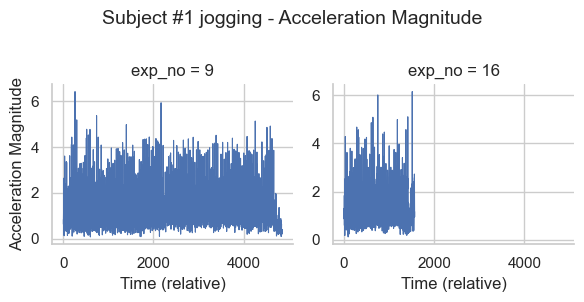

In [27]:
#시각화
g1 = sns.FacetGrid(
    user1_jogging_total,
    col = 'exp_no',
    col_wrap = 2,
    height = 3,
    sharey = False
)
g1.map(plt.plot, 'time', 'maguserAcceleration', linewidth = 0.8)
g1.set_axis_labels('Time (relative)', 'Acceleration Magnitude')
g1.figure.suptitle('Subject #1 jogging - Acceleration Magnitude',
                  y = 1, fontsize = 14)
plt.tight_layout()
plt.show()